# Formative Assignment: Advanced Linear Algebra (PCA)

**Peer Pair:** `[ PEER PAIR 16]`

**Members:**
1. `[Binthia Nitonde]`
2. `[Mutaganzwa Gift Desire]`

**GitHub repo:** `[https://github.com/kenny260/African-Climate-Patterns-PCA.git]`

This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .

1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy (matplotlib is used only for plots)

## Dataset: Rwanda rainfall (HDX HAPI)

**File:** `hdx_hapi_rainfall_rwa.csv`

**Where to find it:** Humanitarian Data Exchange (HDX), dataset **"HDX HAPI Data for Rwanda"**, resource **"Climate: Rainfall for Rwanda"**.

- Dataset page: https://data.humdata.org/dataset/hdx-hapi-rwa
- Direct download of the file: https://data.humdata.org/dataset/80e2fbfc-f027-4b3a-be07-bcd6ae25cb8a/resource/34365a26-1573-416b-8986-4a3a5a938d8d/download/hdx_hapi_rainfall_rwa.csv
- Published by: HDX Humanitarian API (HAPI), UN OCHA. Original rainfall source: Climate Hazards Center, UC Santa Barbara (CHIRPS satellite rainfall estimates) and the World Food Programme (WFP).

**Why it matters:** most Rwandan households depend on rain-fed farming, so rainfall drives harvests, food prices, flood and landslide risk, and therefore economic activity across the country.

The raw file has 20 columns and one row per (region, 10-day period, aggregation window). It has **missing values** (empty `rainfall` and `aggregation_period` cells, plus several completely empty admin columns) and **non-numeric columns** (`aggregation_period`, `version`, the dates, region names and codes).

In [7]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(
    precision=3,
    suppress=True,
    linewidth=120
)

# Raw CSV file from GitHub
DATA_PATH = 'https://raw.githubusercontent.com/kenny260/African-Climate-Patterns-PCA/main/hdx_hapi_rainfall_rwa.csv'

# Load the CSV
table = np.genfromtxt(
    DATA_PATH,
    dtype=str,
    delimiter=',',
    comments=None,
    encoding='utf-8-sig'
)

# Separate header and data
rain_header = table[0].tolist()
rain = table[1:]

# Display information
print('Raw rainfall data shape:', rain.shape)
print('Columns:', rain_header)

# Display first 3 rows
rain[:3]


Raw rainfall data shape: (2550, 20)
Columns: ['location_code', 'has_hrp', 'in_gho', 'provider_admin1_name', 'provider_admin2_name', 'admin1_code', 'admin1_name', 'admin2_code', 'admin2_name', 'admin_level', 'provider_admin1_code', 'provider_admin2_code', 'aggregation_period', 'rainfall', 'rainfall_long_term_average', 'rainfall_anomaly_pct', 'number_pixels', 'version', 'reference_period_start', 'reference_period_end']


array([['RWA', 'False', 'False', 'Not provided', '', '', '', '', '', '1', '900110', '', 'dekad', '44.47826',
        '32.669567', '131.3481', '23', 'final', '2025-10-01', '2025-10-10'],
       ['RWA', 'False', 'False', 'Not provided', '', '', '', '', '', '1', '900110', '', '1-month', '78.04347',
        '81.165215', '96.37703', '23', 'final', '2025-10-01', '2025-10-10'],
       ['RWA', 'False', 'False', 'Not provided', '', '', '', '', '', '1', '900110', '', '3-month', '129.30435',
        '141.35797', '91.76429', '23', 'final', '2025-10-01', '2025-10-10']], dtype='<U26')

## Data inspection: missing values and non-numeric columns

We count the empty cells and the number of different values in every column.

In [9]:
col = {name: i for i, name in enumerate(rain_header)}

print(f'{"column":<28}{"missing":>8}{"unique":>8}   example')
for name in rain_header:
    values = rain[:, col[name]]
    n_missing = (values == '').sum()
    print(f'{name:<28}{n_missing:>8}{len(np.unique(values)):>8}   {values[0]!r}')

column                       missing  unique   example
location_code                      0       1   np.str_('RWA')
has_hrp                            0       1   np.str_('False')
in_gho                             0       1   np.str_('False')
provider_admin1_name               0       1   np.str_('Not provided')
provider_admin2_name            2550       1   np.str_('')
admin1_code                     2550       1   np.str_('')
admin1_name                     2550       1   np.str_('')
admin2_code                     2550       1   np.str_('')
admin2_name                     2550       1   np.str_('')
admin_level                        0       1   np.str_('1')
provider_admin1_code               0       5   np.str_('900110')
provider_admin2_code            2550       1   np.str_('')
aggregation_period                 0       3   np.str_('dekad')
rainfall                           0    2502   np.str_('44.47826')
rainfall_long_term_average         0     540   np.str_('32.669567')
rainfa

What the inspection shows:

- **Completely empty columns** (`provider_admin2_name`, `admin1_code`, `admin1_name`, `admin2_code`, `admin2_name`, `provider_admin2_code`): no information, so they are dropped.
- **Constant columns** (`location_code`, `has_hrp`, `in_gho`, `provider_admin1_name`, `admin_level`): the same value in every row, so their variance is 0 and they cannot be standardized. Dropped.
- **Partly missing columns**: `aggregation_period` and `rainfall` are empty in the same 119 rows. These are the ones we repair below.
- **Non-numeric columns we keep**: `aggregation_period` (dekad / 1-month / 3-month), `version` (final / preliminary / forecast), `reference_period_start` (a date) and `provider_admin1_code` (a region label, not a quantity).

## Handling missing values

**1. `aggregation_period`.** Every (region, date) has exactly three rows, always in the order dekad, 1-month, 3-month. We first check that this rule holds for all rows where the label is present, then use the row position to fill the missing labels.

**2. `rainfall`.** The anomaly column is defined as rainfall divided by the long-term average, so a missing rainfall value can be rebuilt from the two columns that are not missing:

$$\text{rainfall} \approx \text{long-term average} \times \frac{\text{anomaly \%}}{100}$$

This is better than filling with a mean or median, because it uses information from the same row. We measure how accurate the rule is on the rows where rainfall is known before we use it.

In [10]:
period = rain[:, col['aggregation_period']].copy()
period_by_position = np.array(['dekad', '1-month', '3-month'])[np.arange(len(rain)) % 3]

known = period != ''
print('Position rule agrees with every known label:', np.all(period[known] == period_by_position[known]))

period[~known] = period_by_position[~known]
print('Missing aggregation_period after filling   :', (period == '').sum())
print(dict(zip(*np.unique(period, return_counts=True))))

Position rule agrees with every known label: True
Missing aggregation_period after filling   : 0
{np.str_('1-month'): np.int64(850), np.str_('3-month'): np.int64(850), np.str_('dekad'): np.int64(850)}


In [11]:
rain_text = rain[:, col['rainfall']]
rainfall = np.where(rain_text == '', 'nan', rain_text).astype(float)
long_term_avg = rain[:, col['rainfall_long_term_average']].astype(float)
anomaly_pct = rain[:, col['rainfall_anomaly_pct']].astype(float)

estimate = long_term_avg * anomaly_pct / 100
was_missing = np.isnan(rainfall)

# how good is the rule on rows where we know the true rainfall?
print(f'{"period":<9}{"missing":>8}{"mean rainfall (mm)":>20}{"mean abs error (mm)":>21}')
for p in ['dekad', '1-month', '3-month']:
    m = (period == p) & ~was_missing
    error = np.abs(estimate[m] - rainfall[m]).mean()
    print(f'{p:<9}{(was_missing & (period == p)).sum():>8}{rainfall[m].mean():>20.1f}{error:>21.2f}')

rainfall[was_missing] = estimate[was_missing]
print('\nMissing rainfall values after imputation:', np.isnan(rainfall).sum())

period    missing  mean rainfall (mm)  mean abs error (mm)
dekad           0                31.1                 1.83
1-month         0                93.8                 1.51
3-month         0               286.3                 0.96

Missing rainfall values after imputation: 0


## Reshaping: one row per region per 10-day period

PCA needs each row to be one observation described by the same features. We turn the three aggregation windows into columns, so each row is one (region, 10-day period) with 9 numeric measurements: rainfall, long-term average and anomaly, each for the dekad, 1-month and 3-month window. This also handles the non-numeric `aggregation_period` column, because its categories become column names.

In [12]:
periods = ['dekad', '1-month', '3-month']
region = rain[:, col['provider_admin1_code']]
start_date = rain[:, col['reference_period_start']]

key = np.char.add(np.char.add(region, '|'), start_date)
keys, row_of = np.unique(key, return_inverse=True)
period_of = np.array([periods.index(p) for p in period])

def to_wide(values):
    wide = np.full((len(keys), len(periods)), np.nan)
    wide[row_of, period_of] = values
    return wide

measurements = np.column_stack([to_wide(rainfall), to_wide(long_term_avg), to_wide(anomaly_pct)])
measurement_names = ([f'rain_{p}' for p in periods] + [f'avg_{p}' for p in periods] + [f'anomaly_{p}' for p in periods])
measurement_names = [n.replace('-', '') for n in measurement_names]

first = np.unique(row_of, return_index=True)[1]   # one raw row per (region, date)
row_region = region[first]
row_date = start_date[first]
row_version = rain[first, col['version']]

print('Reshaped data shape:', measurements.shape, '| empty cells left:', np.isnan(measurements).sum())
print('Columns:', measurement_names)
measurements[:5]

Reshaped data shape: (850, 9) | empty cells left: 0
Columns: ['rain_dekad', 'rain_1month', 'rain_3month', 'avg_dekad', 'avg_1month', 'avg_3month', 'anomaly_dekad', 'anomaly_1month', 'anomaly_3month']


array([[ 10.87 , 100.696, 314.565,  22.783,  82.575, 319.277,  57.121, 120.691,  98.547],
       [ 43.478, 108.   , 315.87 ,  21.606,  79.462, 303.049, 182.209, 133.787, 104.162],
       [ 24.217,  78.565, 280.174,  24.972,  69.361, 283.128,  97.481, 112.378,  98.975],
       [ 35.435, 103.13 , 295.609,  26.693,  73.271, 264.588, 127.584, 138.149, 111.507],
       [ 64.652, 124.304, 328.348,  32.303,  83.968, 259.304, 186.721, 145.338, 126.123]])

## Encoding non-numeric columns

- `reference_period_start` (date) -> numeric **year**, plus the **month** written as `month_sin` and `month_cos`. Months are a cycle (December is next to January), and sine/cosine keep that, while the plain numbers 1 to 12 would put December far from January.
- `provider_admin1_code` (5 regions, no natural order) -> **one-hot encoding with one category dropped** (the first region is the reference). If we kept all 5 dummy columns they would always sum to 1, which gives the covariance matrix an eigenvalue of exactly 0.
- `version` (final / preliminary / forecast) -> one binary column **`is_final`** (1 = confirmed measurement, 0 = preliminary or forecast).
- `number_pixels` and `reference_period_end` are not used: the pixel count is fixed per region (same information as the region dummies) and the end date is the start date plus about 10 days.

In [13]:
year = np.array([d[:4] for d in row_date], dtype=float)
month = np.array([d[5:7] for d in row_date], dtype=float)
month_sin = np.sin(2 * np.pi * month / 12)
month_cos = np.cos(2 * np.pi * month / 12)

regions = np.unique(row_region)
dummy_regions = regions[1:]   # drop the first category (reference region)
region_onehot = (row_region[:, None] == dummy_regions[None, :]).astype(float)

is_final = (row_version == 'final').astype(float)

print('Regions:', regions.tolist(), '| reference (dropped):', regions[0])
print('Versions:', dict(zip(*np.unique(row_version, return_counts=True))))

Regions: ['900110', '900111', '900112', '900113', '900114'] | reference (dropped): 900110
Versions: {np.str_('final'): np.int64(840), np.str_('preliminary'): np.int64(10)}


In [14]:
X = np.column_stack([measurements, year, month_sin, month_cos, region_onehot, is_final])
feature_names = measurement_names + ['year', 'month_sin', 'month_cos'] + ['region_' + r for r in dummy_regions] + ['is_final']

print('Final feature matrix shape:', X.shape)
print('Features:', feature_names)
print('Any missing values left:', np.isnan(X).any())
X[:5]

Final feature matrix shape: (850, 17)
Features: ['rain_dekad', 'rain_1month', 'rain_3month', 'avg_dekad', 'avg_1month', 'avg_3month', 'anomaly_dekad', 'anomaly_1month', 'anomaly_3month', 'year', 'month_sin', 'month_cos', 'region_900111', 'region_900112', 'region_900113', 'region_900114', 'is_final']
Any missing values left: False


array([[  10.87 ,  100.696,  314.565,   22.783,   82.575,  319.277,   57.121,  120.691,   98.547, 2022.   ,    0.5  ,
           0.866,    0.   ,    0.   ,    0.   ,    0.   ,    1.   ],
       [  43.478,  108.   ,  315.87 ,   21.606,   79.462,  303.049,  182.209,  133.787,  104.162, 2022.   ,    0.5  ,
           0.866,    0.   ,    0.   ,    0.   ,    0.   ,    1.   ],
       [  24.217,   78.565,  280.174,   24.972,   69.361,  283.128,   97.481,  112.378,   98.975, 2022.   ,    0.5  ,
           0.866,    0.   ,    0.   ,    0.   ,    0.   ,    1.   ],
       [  35.435,  103.13 ,  295.609,   26.693,   73.271,  264.588,  127.584,  138.149,  111.507, 2022.   ,    0.866,
           0.5  ,    0.   ,    0.   ,    0.   ,    0.   ,    1.   ],
       [  64.652,  124.304,  328.348,   32.303,   83.968,  259.304,  186.721,  145.338,  126.123, 2022.   ,    0.866,
           0.5  ,    0.   ,    0.   ,    0.   ,    0.   ,    1.   ]])

### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

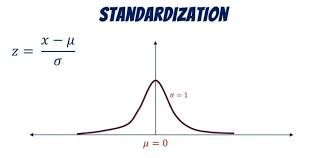


In [15]:
# Step 1: Load and Standardize the data (use of numpy only allowed)
mean = X.sum(axis=0) / X.shape[0]                            # mu for each feature
std = np.sqrt(((X - mean) ** 2).sum(axis=0) / X.shape[0])    # sigma for each feature

standardized_data = (X - mean) / std  # z = (x - mu) / sigma  (Do not use sklearn)

print('Means after standardization   :', standardized_data.mean(axis=0).round(6))
print('Std devs after standardization:', standardized_data.std(axis=0).round(6))
standardized_data[:5]  # Display the first few rows of standardized data

Means after standardization   : [-0.  0. -0. -0.  0.  0.  0.  0. -0. -0. -0. -0. -0.  0.  0.  0. -0.]
Std devs after standardization: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


array([[-0.775,  0.107,  0.208, -0.472, -0.207,  0.333, -0.87 ,  0.586, -0.02 , -1.377,  0.661,  1.294, -0.5  ,
        -0.5  , -0.5  , -0.5  ,  0.109],
       [ 0.475,  0.222,  0.218, -0.541, -0.271,  0.189,  1.738,  0.93 ,  0.203, -1.377,  0.661,  1.294, -0.5  ,
        -0.5  , -0.5  , -0.5  ,  0.109],
       [-0.264, -0.239, -0.045, -0.343, -0.479,  0.013, -0.029,  0.368, -0.003, -1.377,  0.661,  1.294, -0.5  ,
        -0.5  , -0.5  , -0.5  ,  0.109],
       [ 0.166,  0.145,  0.068, -0.242, -0.399, -0.151,  0.599,  1.044,  0.494, -1.377,  1.176,  0.772, -0.5  ,
        -0.5  , -0.5  , -0.5  ,  0.109],
       [ 1.286,  0.477,  0.31 ,  0.088, -0.178, -0.197,  1.832,  1.232,  1.074, -1.377,  1.176,  0.772, -0.5  ,
        -0.5  , -0.5  , -0.5  ,  0.109]])

### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [16]:
# Step 3: Calculate the Covariance Matrix
n = standardized_data.shape[0]
cov_matrix = (standardized_data.T @ standardized_data) / (n - 1)  # the data is already centred

print('Shape:', cov_matrix.shape, '| symmetric:', np.allclose(cov_matrix, cov_matrix.T))
cov_matrix

Shape: (17, 17) | symmetric: True


array([[ 1.001,  0.792,  0.414,  0.693,  0.69 ,  0.406,  0.725,  0.446,  0.209, -0.074,  0.295,  0.344, -0.098,
         0.038,  0.098,  0.048,  0.058],
       [ 0.792,  1.001,  0.655,  0.739,  0.821,  0.632,  0.411,  0.62 ,  0.322, -0.081,  0.429,  0.345, -0.12 ,
         0.046,  0.118,  0.059,  0.113],
       [ 0.414,  0.655,  1.001,  0.385,  0.574,  0.901,  0.236,  0.394,  0.598, -0.027,  0.666,  0.133, -0.17 ,
         0.063,  0.167,  0.086,  0.192],
       [ 0.693,  0.739,  0.385,  1.001,  0.94 ,  0.486,  0.086,  0.113,  0.029, -0.047,  0.44 ,  0.425, -0.139,
         0.039,  0.143,  0.054,  0.021],
       [ 0.69 ,  0.821,  0.574,  0.94 ,  1.001,  0.696,  0.116,  0.157,  0.081, -0.044,  0.528,  0.358, -0.145,
         0.039,  0.151,  0.058,  0.067],
       [ 0.406,  0.632,  0.901,  0.486,  0.696,  1.001,  0.122,  0.195,  0.262,  0.002,  0.719,  0.077, -0.187,
         0.048,  0.197,  0.077,  0.181],
       [ 0.725,  0.411,  0.236,  0.086,  0.116,  0.122,  1.001,  0.596,  0.348, -0

In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons

**Answer:** First, the covariance matrix shows how every pair of features varies together, so it reveals redundancy: here the dekad, 1-month and 3-month rainfall columns rise and fall together, which means several columns repeat the same information. Second, its eigenvectors are the directions of greatest variance in the data and its eigenvalues are the amount of variance along each one, so PCA cannot find or rank the principal components without it. Because the data is standardized, it is also the correlation matrix, so every feature is compared on the same scale.

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [17]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)  # eigh: made for symmetric matrices

# check: C v = lambda v for every pair
print('C v = lambda v holds:', np.allclose(cov_matrix @ eigenvectors, eigenvectors * eigenvalues))
eigenvalues, eigenvectors

C v = lambda v holds: True


(array([0.01 , 0.022, 0.029, 0.067, 0.219, 0.333, 0.361, 0.498, 0.762, 0.853, 1.122, 1.234, 1.251, 1.252, 1.643, 1.96 ,
        5.404]),
 array([[-0.226, -0.458,  0.385,  0.405, -0.028,  0.074, -0.188,  0.188, -0.006, -0.303,  0.088,  0.03 ,  0.003,
         -0.006, -0.34 ,  0.12 , -0.345],
        [ 0.399,  0.121, -0.409,  0.529, -0.087, -0.014,  0.221, -0.377, -0.021, -0.033,  0.025, -0.012, -0.001,
         -0.003, -0.138,  0.036, -0.396],
        [-0.332,  0.545,  0.307,  0.217, -0.155,  0.29 ,  0.129,  0.116, -0.119,  0.162,  0.049,  0.013, -0.002,
         -0.001,  0.384, -0.009, -0.35 ],
        [ 0.366,  0.323,  0.415, -0.312,  0.07 , -0.064, -0.374, -0.211,  0.065, -0.012, -0.078, -0.063,  0.013,
         -0.   , -0.299, -0.298, -0.326],
        [-0.569, -0.079, -0.479, -0.326, -0.121,  0.113, -0.11 , -0.186,  0.005, -0.049, -0.049, -0.066,  0.004,
          0.   , -0.165, -0.3  , -0.366],
        [ 0.371, -0.452,  0.092, -0.337, -0.128,  0.26 ,  0.383,  0.15 , -0.108, -0.048,

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [18]:
# Step 5: Sort Principal Components
sorted_indices = np.argsort(eigenvalues)[::-1]  # Sort eigenvalues in descending order
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]  # Sort eigenvectors accordingly (columns = PCs)

print('Sorted eigenvalues:', sorted_eigenvalues)
sorted_eigenvectors

Sorted eigenvalues: [5.404 1.96  1.643 1.252 1.251 1.234 1.122 0.853 0.762 0.498 0.361 0.333 0.219 0.067 0.029 0.022 0.01 ]


array([[-0.345,  0.12 , -0.34 , -0.006,  0.003,  0.03 ,  0.088, -0.303, -0.006,  0.188, -0.188,  0.074, -0.028,
         0.405,  0.385, -0.458, -0.226],
       [-0.396,  0.036, -0.138, -0.003, -0.001, -0.012,  0.025, -0.033, -0.021, -0.377,  0.221, -0.014, -0.087,
         0.529, -0.409,  0.121,  0.399],
       [-0.35 , -0.009,  0.384, -0.001, -0.002,  0.013,  0.049,  0.162, -0.119,  0.116,  0.129,  0.29 , -0.155,
         0.217,  0.307,  0.545, -0.332],
       [-0.326, -0.298, -0.299, -0.   ,  0.013, -0.063, -0.078, -0.012,  0.065, -0.211, -0.374, -0.064,  0.07 ,
        -0.312,  0.415,  0.323,  0.366],
       [-0.366, -0.3  , -0.165,  0.   ,  0.004, -0.066, -0.049, -0.049,  0.005, -0.186, -0.11 ,  0.113, -0.121,
        -0.326, -0.479, -0.079, -0.569],
       [-0.339, -0.215,  0.325,  0.005, -0.009,  0.002,  0.04 , -0.048, -0.108,  0.15 ,  0.383,  0.26 , -0.128,
        -0.337,  0.092, -0.452,  0.371],
       [-0.194,  0.48 , -0.188, -0.001, -0.01 ,  0.102,  0.199, -0.356, -0.044,  0

### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [ ]:
# Step 6: Project Data onto Principal Components
num_components = None  # Decide on the number of principal components to keep
reduced_data = None  # Project data onto the principal components
reduced_data[:5]

### Task 2: Explained variance and dynamic selection of components

Each eigenvalue is the variance captured by its principal component, so

$$\text{explained variance ratio}_i = \frac{\lambda_i}{\sum_j \lambda_j}$$

Instead of typing in a fixed number, we keep the smallest number of components whose cumulative explained variance reaches a chosen threshold. We also print the Kaiser rule (eigenvalue > 1) for comparison.

In [19]:
explained_variance_ratio = sorted_eigenvalues / sorted_eigenvalues.sum()
cumulative_variance = np.cumsum(explained_variance_ratio)

print(f'{"PC":<5}{"eigenvalue":>11}{"explained":>11}{"cumulative":>12}')
for i, (ev, r, c) in enumerate(zip(sorted_eigenvalues, explained_variance_ratio, cumulative_variance), 1):
    print(f'PC{i:<3}{ev:>11.3f}{r:>11.2%}{c:>12.2%}')

PC    eigenvalue  explained  cumulative
PC1        5.404     31.75%      31.75%
PC2        1.960     11.51%      43.27%
PC3        1.643      9.65%      52.92%
PC4        1.252      7.35%      60.27%
PC5        1.251      7.35%      67.62%
PC6        1.234      7.25%      74.87%
PC7        1.122      6.59%      81.46%
PC8        0.853      5.01%      86.48%
PC9        0.762      4.48%      90.96%
PC10       0.498      2.92%      93.88%
PC11       0.361      2.12%      96.00%
PC12       0.333      1.96%      97.96%
PC13       0.219      1.28%      99.24%
PC14       0.067      0.39%      99.64%
PC15       0.029      0.17%      99.81%
PC16       0.022      0.13%      99.94%
PC17       0.010      0.06%     100.00%


In [20]:
def select_num_components(eigvals_sorted, threshold=0.90):
    """Smallest k such that the first k components explain >= threshold of the total variance."""
    cumulative = np.cumsum(eigvals_sorted) / eigvals_sorted.sum()
    return int(np.searchsorted(cumulative, threshold) + 1)

VARIANCE_THRESHOLD = 0.90  # <- team decision, justified in the answers below

for thr in [0.70, 0.80, 0.85, 0.90, 0.95]:
    print(f'threshold {thr:.0%} -> {select_num_components(sorted_eigenvalues, thr)} components')
print('Kaiser rule (eigenvalue > 1) ->', int((sorted_eigenvalues > 1).sum()), 'components')

threshold 70% -> 6 components
threshold 80% -> 7 components
threshold 85% -> 8 components
threshold 90% -> 9 components
threshold 95% -> 11 components
Kaiser rule (eigenvalue > 1) -> 7 components


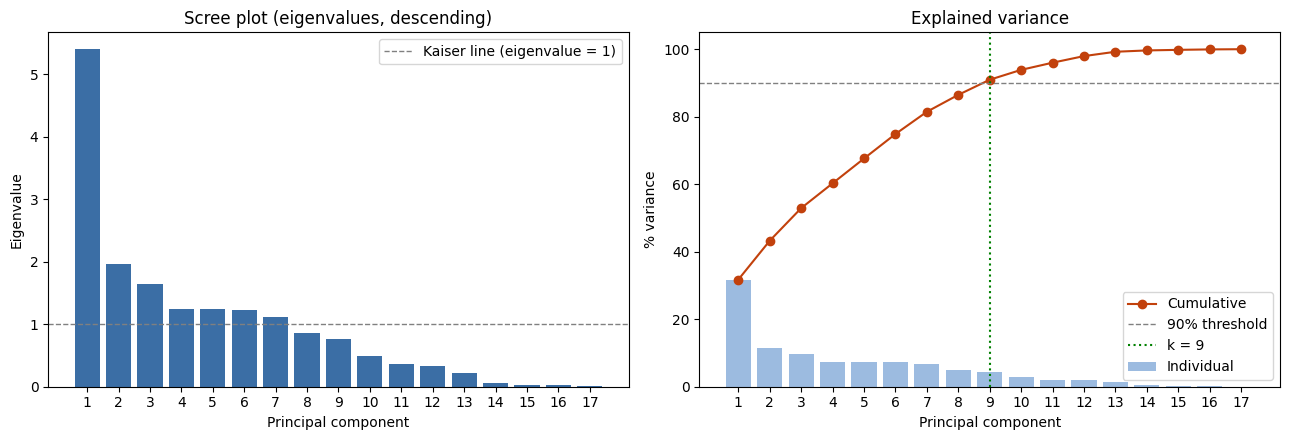

In [21]:
k_sel = select_num_components(sorted_eigenvalues, VARIANCE_THRESHOLD)
pcs = np.arange(1, len(sorted_eigenvalues) + 1)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].bar(pcs, sorted_eigenvalues, color='#3b6ea5')
ax[0].axhline(1, color='gray', ls='--', lw=1, label='Kaiser line (eigenvalue = 1)')
ax[0].set(title='Scree plot (eigenvalues, descending)', xlabel='Principal component', ylabel='Eigenvalue', xticks=pcs)
ax[0].legend()

ax[1].bar(pcs, explained_variance_ratio * 100, color='#9cbbe0', label='Individual')
ax[1].plot(pcs, cumulative_variance * 100, 'o-', color='#c2410c', label='Cumulative')
ax[1].axhline(VARIANCE_THRESHOLD * 100, color='gray', ls='--', lw=1, label=f'{VARIANCE_THRESHOLD:.0%} threshold')
ax[1].axvline(k_sel, color='green', ls=':', lw=1.5, label=f'k = {k_sel}')
ax[1].set(title='Explained variance', xlabel='Principal component', ylabel='% variance', xticks=pcs)
ax[1].legend()

plt.tight_layout(); plt.show()

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [ ]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')  # Display reduced data shape
reduced_data[:5]  # Display the first few rows of reduced data

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

In [ ]:
# Step 8: Visualize Before and After PCA


# Plot original data (first two features for simplicity)


# Plot reduced data after PCA


Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA
2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making
3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?
